In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


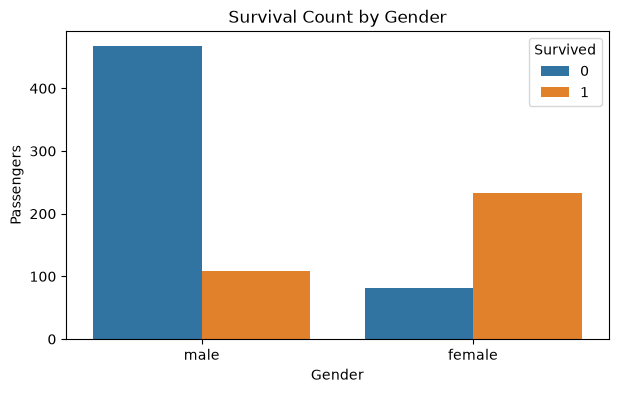

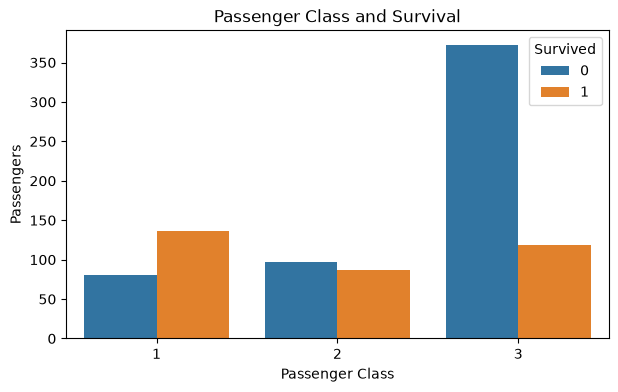

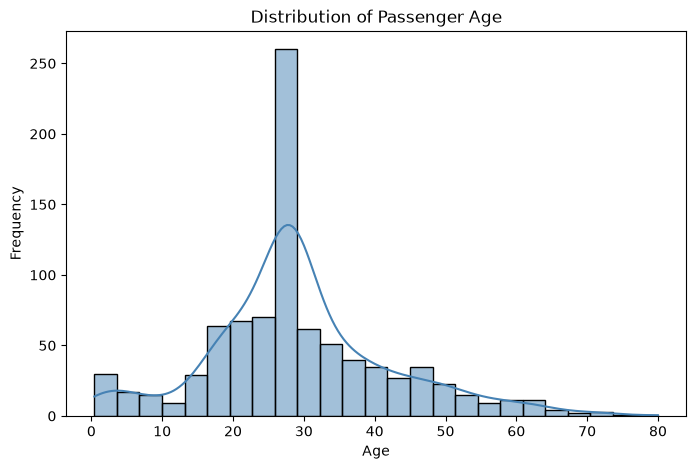

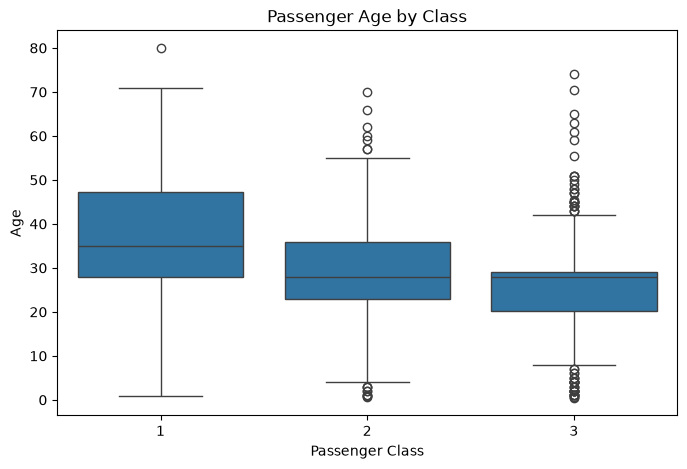

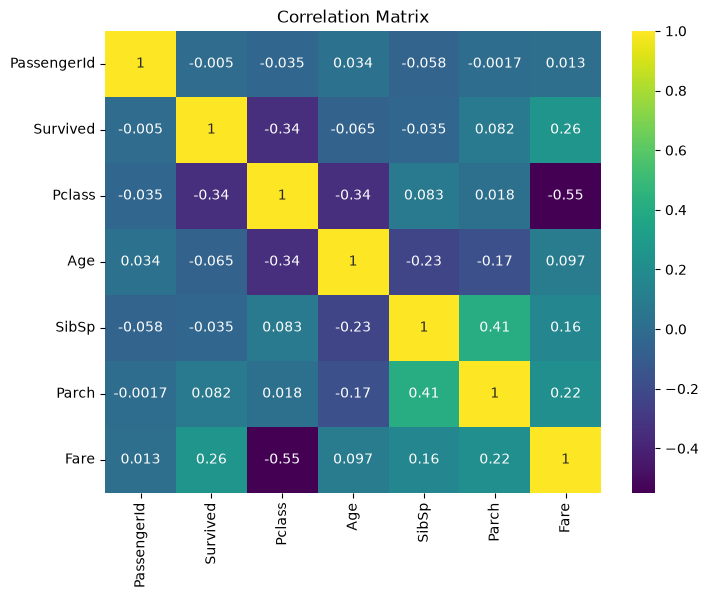

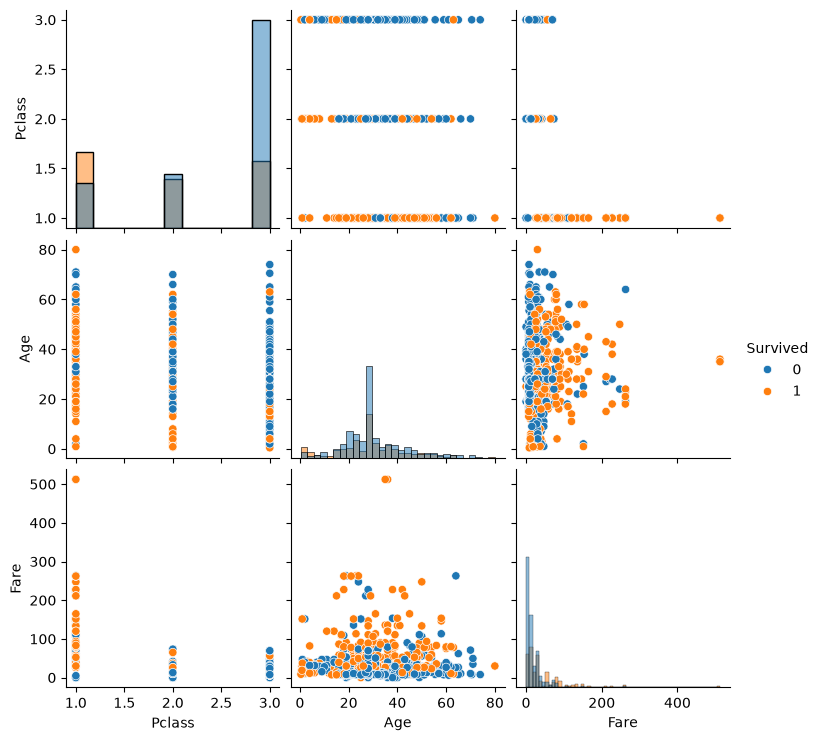

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
titanic = pd.read_csv("train.csv")

print(titanic.info())

titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])
titanic.drop(columns=["Cabin"], inplace=True)


plt.figure(figsize=(7, 4))
sns.countplot(data=titanic, x="Sex", hue="Survived")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Passengers")
plt.show()

# Survival by Passenger Class
plt.figure(figsize=(7, 4))
sns.countplot(data=titanic, x="Pclass", hue="Survived")
plt.title("Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Passengers")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=titanic, x="Age", bins=25, kde=True, color="steelblue")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=titanic, x="Pclass", y="Age")
plt.title("Passenger Age by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(8, 6))
numeric_df = titanic.select_dtypes(include="number")
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Correlation Matrix")
plt.show()

sns.pairplot(
    titanic[["Survived", "Pclass", "Age", "Fare"]].dropna(),
    hue="Survived",
    diag_kind="hist"
)
plt.show()